# Task-loss landscape over the squeezing controls (Mackey–Glass)

## Statement of the problem
Does squeezing merely rescale the reservoir output, or does it reshape the task loss $\mathcal L(\vartheta)=\frac{1}{2N_{\rm tr}}\|y-X(\vartheta)w^\star(\vartheta)\|^2$ (readout refit at every setting) in a way that experimentally accessible controls can navigate?

**Task.** Ten-step Mackey–Glass prediction ($\beta,\gamma,n,\tau)=(0.2,0.1,10,17)$, unit-step Euler, 1000 samples: 100 washout, 700 training, 190 held out.

**Protocol.** Coarse $6\times6\times12$ scan of $(r,r_e,\Delta\theta)\in[0,0.5]^2\times[-\pi,\pi]$; dense $25\times25$ slices $\mathcal L(r,\Delta\theta)$ at the best $r_e$ and $\mathcal L(r,r_e)$ at the best phase; projected finite-difference gradient descent restricted to each slice (4 random starts, 60 evaluations); Fock-cutoff mask (cells where $\mathcal L$ changes $>1\%$ between $N_c=8$ and 12).

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


## Compute
`run_fig2.py` (~25 min on one core) writes `data/fig2_scans.npz` and `data/fig2_paths.npz`.

In [2]:
if RUN: subprocess.run(['python3', 'run_fig2.py'])
sc = ld('fig2_scans.npz'); L3 = sc['L3']; L0 = L3[0, 0, 0]; i, j, k = np.unravel_index(L3.argmin(), L3.shape)
print('unsqueezed L0 = %.4e (NRMSE %.3f)' % (L0, sc['N3'][0, 0, 0]))
print('coarse optimum (r, re, dth) = (%.2f, %.2f, %.2f): L = %.4e, reduction %.1f%%' % (sc['r3'][i], sc['re3'][j], sc['d3'][k], L3.min(), 100 * (1 - L3.min() / L0)))
print('dense-slice optimum: L = %.4e (%.1f%%), NRMSE %.3f' % (sc['L1'].min(), 100 * (1 - sc['L1'].min() / L0), sc['NR1'].ravel()[sc['L1'].argmin()]))
print('intracavity squeezing alone (re=0): best %.1f%% at r = %.2f' % (100 * (1 - sc['L2'][:, 0].min() / L0), sc['rg'][sc['L2'][:, 0].argmin()]))

unsqueezed L0 = 7.0840e-03 (NRMSE 0.521)
coarse optimum (r, re, dth) = (0.00, 0.20, -0.52): L = 4.6493e-03, reduction 34.4%
dense-slice optimum: L = 4.6392e-03 (34.5%), NRMSE 0.431
intracavity squeezing alone (re=0): best 13.9% at r = 0.15


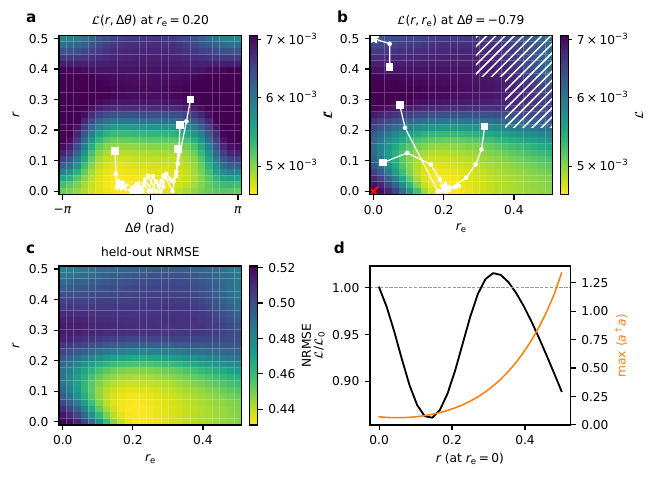

In [3]:
make_figs.fig2(); show('paper/figs/fig2_landscape.pdf')

**Figure 2.** (a) $\mathcal L(r,\Delta\theta)$ at $r_e=0.2$ with gradient trajectories (squares: start, stars: end). (b) $\mathcal L(r,r_e)$ at $\Delta\theta=-0.79$; $\times$ unsqueezed; hatched cells fail the Fock-cutoff check. (c) Held-out NRMSE shares the basin. (d) Along $r_e=0$, intracavity squeezing alone has an interior optimum near $r\approx0.14$; with external squeezing on, the optimum moves to $r\approx0$.

Interpretation: the $(r_e,\Delta\theta)$ basin is the emitter channel (phase-sensitive relaxation), the $r$ dependence is the linear-response channel (input de-amplified by $e^{-r}$, cavity detuned).